In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [2]:
df_clean = pd.read_csv("../Analyst Data/df_clean.csv")
display(df_clean)

,transaction_id,user_id,transaction_amount,transaction_type,transaction_time,location,is_foreign_transaction,device_type,is_new_device,is_new_location,account_age_days,avg_transaction_amount,transactions_last_24h,failed_logins_24h,time_since_last_txn,txn_hour,is_weekend,is_fraud
0,T0086548,U9625,5068.33,NEFT,2024-09-25 02:47:00,Delhi,0,Tablet,0,1,3124,4957.53,1,0,947,2,0,0
1,T0088155,U9783,3428.09,IMPS,2024-06-23 07:32:00,Delhi,0,Mobile,0,1,2302,3750.88,0,0,902,7,1,0
2,T0076282,U8629,5161.81,NEFT,2024-06-02 16:01:00,Mumbai,0,Mobile,0,0,1157,4075.63,5,0,893,16,1,0
3,T0013138,U2319,4242.40,UPI,2024-01-30 01:36:00,Chennai,0,Tablet,0,0,613,3745.28,2,1,1139,1,0,0
4,T0060581,U7056,1721.96,UPI,2024-07-02 06:52:00,Hyderabad,0,Desktop,0,0,637,2818.78,1,0,710,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100181,T0006917,U1697,5583.41,POS,2024-01-31 21:28:00,Chennai,0,Desktop,1,0,1967,4426.44,3,0,1365,21,0,0
100182,T0061003,U7095,4467.45,UPI,2024-08-05 12:55:00,Chennai,0,Mobile,0,0,2927,4169.89,4,0,179,12,0,0
100183,T0085361,U9503,3608.26,POS,2024-05-30 21:50:00,Chennai,0,Mobile,0,0,1431,2558.02,1,1,340,21,0,0
100184,T0000894,U1089,4174.99,ATM Withdrawal,2024-05-13 13:56:00,Kolkata,0,Desktop,0,1,309,3810.77,4,0,949,13,0,0


In [3]:
# Convert Time Column
df_clean['transaction_time'] = pd.to_datetime(df_clean['transaction_time'])

df_clean['txn_hour'] = df_clean['transaction_time'].dt.hour
df_clean['txn_day'] = df_clean['transaction_time'].dt.day
df_clean['txn_month'] = df_clean['transaction_time'].dt.month
df_clean['txn_dayofweek'] = df_clean['transaction_time'].dt.dayofweek

df_clean['is_weekend'] = df_clean['txn_dayofweek'].isin([5,6]).astype(int)

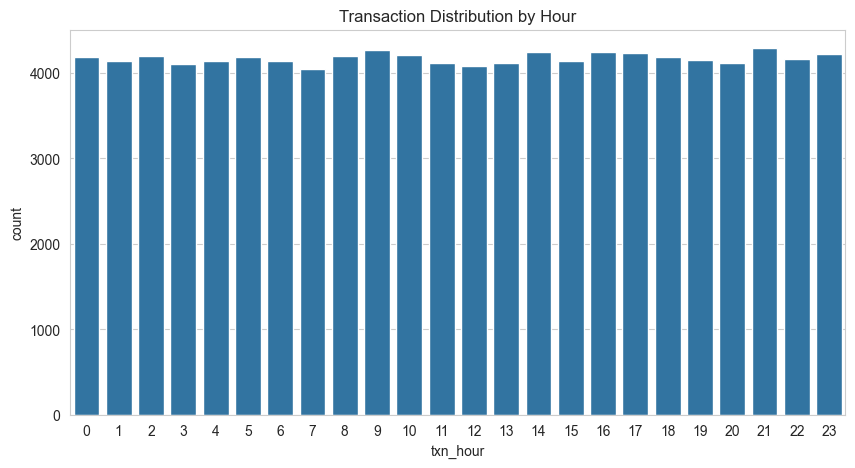

In [4]:
plt.figure(figsize=(10,5))
sns.countplot(x='txn_hour', data=df_clean)
plt.title("Transaction Distribution by Hour")
plt.show()

In [5]:
def feature_engineer(df_clean, target="is_fraud"):
    """
    Perform feature engineering for fraud detection dataset.
    
    Parameters
    ----------
    df_clean : pd.DataFrame
        Original dataframe containing transaction data
    target : str, optional
        Target column name, default is "is_fraud"
        
    Returns
    -------
    df_fe : pd.DataFrame
        Dataframe with engineered fraud detection features
    """
    
    df_fe = df_clean.copy()

    # Transaction spike detection
    if "transaction_amount" in df_fe.columns and "avg_transaction_amount" in df_fe.columns:
        df_fe["amount_ratio"] = df_fe["transaction_amount"] / (
            df_fe["avg_transaction_amount"] + 1
        )
    
    # User activity intensity
    if "transactions_last_24h" in df_fe.columns:
        df_fe["txn_per_day"] = df_fe["transactions_last_24h"] / 24
    
    # Account trust score
    if "account_age_days" in df_fe.columns and "failed_logins_24h" in df_fe.columns:
        df_fe["account_trust_score"] = df_fe["account_age_days"] / (
            df_fe["failed_logins_24h"] + 1
        )
    
    # Device Risk Feature
    device_cols = [
        "is_new_device",
        "is_new_location",
        "is_foreign_transaction"
    ]
    
    existing_cols = [c for c in device_cols if c in df_fe.columns]
    
    if existing_cols:
        df_fe["device_risk"] = df_fe[existing_cols].sum(axis=1)
    
    # Time Risk Feature    
    if "txn_hour" in df_fe.columns:
        df_fe["night_transaction"] = df_fe["txn_hour"].apply(
            lambda x: 1 if x <= 5 else 0
        )
    
    # Encode categorical columns
    cat_cols = df_fe.select_dtypes(include="object").columns
    
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    
    for col in cat_cols:
        df_fe[col] = le.fit_transform(df_fe[col])
    
    
    return df_fe

df_fe = feature_engineer(df_clean)

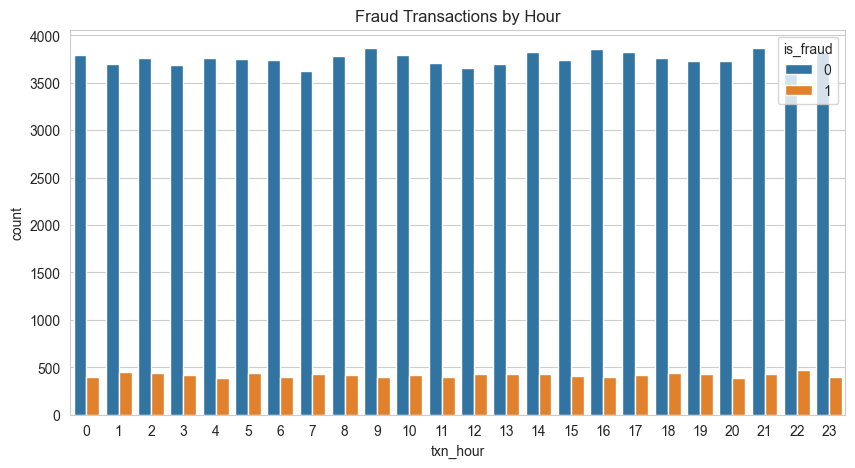

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(x='txn_hour', hue='is_fraud', data=df_fe)
plt.title("Fraud Transactions by Hour")
plt.show()

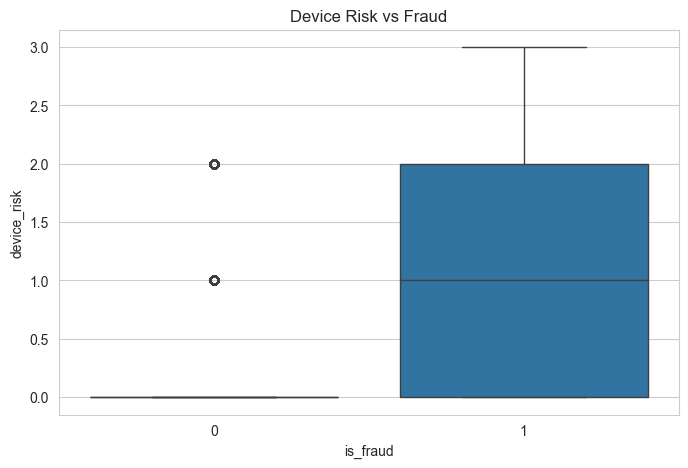

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='device_risk', data=df_fe)
plt.title("Device Risk vs Fraud")
plt.show()

In [8]:
fraud_features = df_fe.groupby('is_fraud').mean(numeric_only=True)

display(fraud_features.T)

is_fraud,0,1
transaction_id,50144.985072,49620.102915
user_id,5025.189213,5009.943701
transaction_amount,4000.137092,4483.995557
transaction_type,2.801471,2.811240
location,2.522624,2.505989
is_foreign_transaction,0.040081,0.237772
device_type,0.896538,0.903574
is_new_device,0.056495,0.435217
is_new_location,0.082579,0.431823
account_age_days,1852.349026,1859.344081


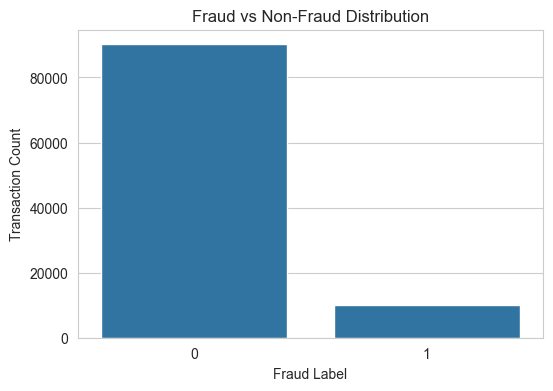

is_fraud
0    0.900006
1    0.099994
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df_fe)

plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count")

plt.show()

print(df_fe['is_fraud'].value_counts(normalize=True))

In [10]:
df_final = df_fe
df_final.to_csv("df_final.csv", index=False)

In [11]:
X = df_fe.drop(columns=[
    'transaction_id',
    'user_id',
    'transaction_time',
    'is_fraud'
])

y = df_fe['is_fraud']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

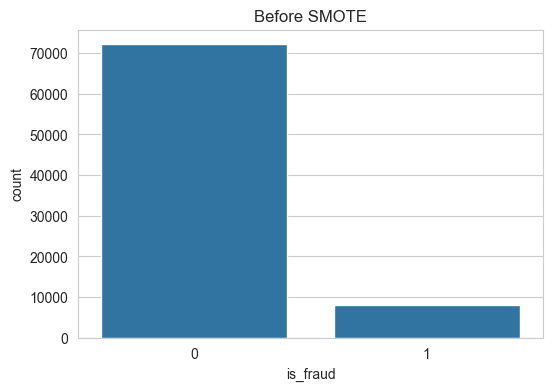

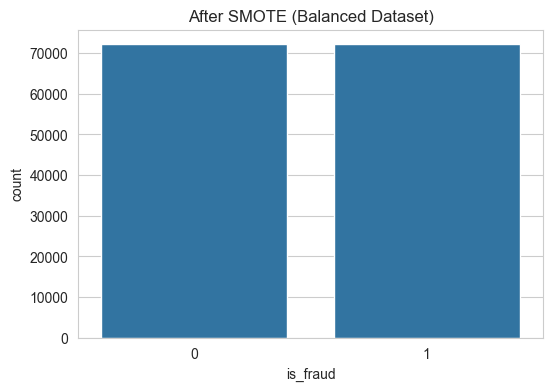

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Before SMOTE")
plt.show()

plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("After SMOTE (Balanced Dataset)")
plt.show()

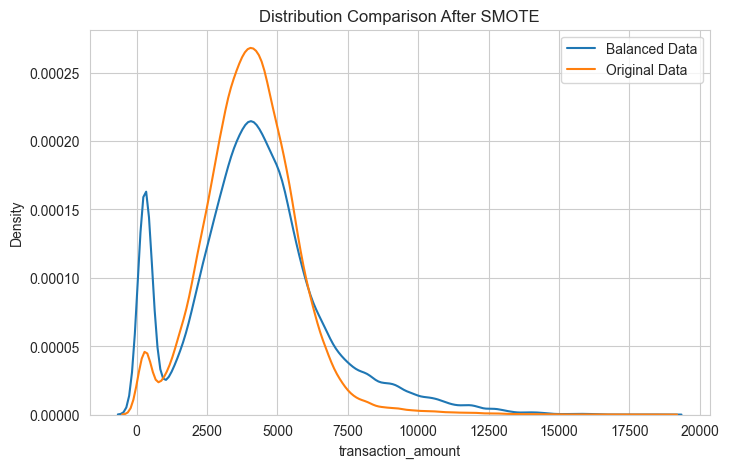

In [15]:
plt.figure(figsize=(8,5))

sns.kdeplot(X_train_smote['transaction_amount'], label='Balanced Data')

sns.kdeplot(X_train['transaction_amount'], label='Original Data')

plt.legend()

plt.title("Distribution Comparison After SMOTE")

plt.show()

In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [17]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42
)

In [18]:
param_grid = {
    'max_depth': [4,6,8],
    'learning_rate': [0.01,0.05,0.1],
    'n_estimators': [200,400],
    'subsample': [0.8,1],
    'colsample_bytree': [0.8,1]
}

In [19]:
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kfold,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}


In [21]:
eval_set = [(X_train_smote, y_train_smote), (X_test, y_test)]

best_model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=eval_set,
    verbose=True
)

[0]	validation_0-auc:0.94281	validation_1-auc:0.89948
[1]	validation_0-auc:0.96468	validation_1-auc:0.90194
[2]	validation_0-auc:0.96548	validation_1-auc:0.90229
[3]	validation_0-auc:0.96666	validation_1-auc:0.90229
[4]	validation_0-auc:0.97571	validation_1-auc:0.90398
[5]	validation_0-auc:0.97535	validation_1-auc:0.90379
[6]	validation_0-auc:0.97580	validation_1-auc:0.90447
[7]	validation_0-auc:0.97741	validation_1-auc:0.90541
[8]	validation_0-auc:0.97824	validation_1-auc:0.90641
[9]	validation_0-auc:0.97888	validation_1-auc:0.90700
[10]	validation_0-auc:0.97929	validation_1-auc:0.90691
[11]	validation_0-auc:0.97933	validation_1-auc:0.90689
[12]	validation_0-auc:0.98003	validation_1-auc:0.90682
[13]	validation_0-auc:0.98048	validation_1-auc:0.90805
[14]	validation_0-auc:0.98058	validation_1-auc:0.90879
[15]	validation_0-auc:0.98102	validation_1-auc:0.90903
[16]	validation_0-auc:0.98124	validation_1-auc:0.90821
[17]	validation_0-auc:0.98173	validation_1-auc:0.90883
[18]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

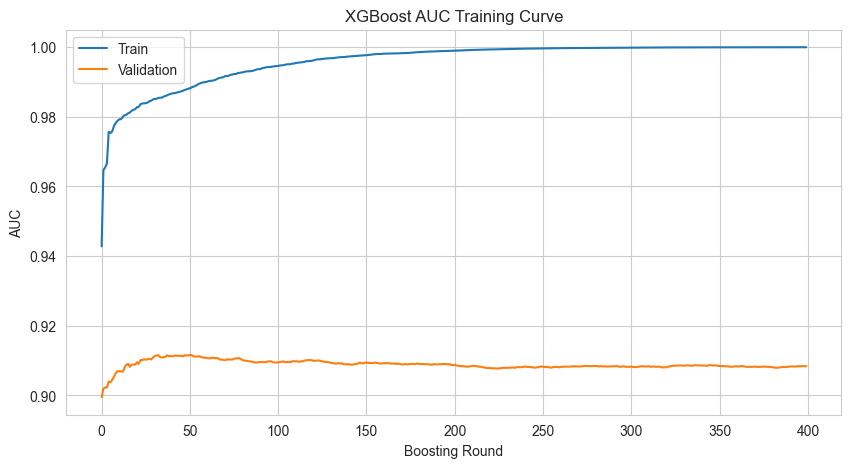

In [22]:
results = best_model.evals_result()

epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(10,5))

plt.plot(x_axis, results['validation_0']['auc'], label='Train')
plt.plot(x_axis, results['validation_1']['auc'], label='Validation')

plt.title("XGBoost AUC Training Curve")
plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.legend()

plt.show()

In [23]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [24]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("ROC AUC:", roc_auc_score(y_test,y_prob))

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Accuracy: 0.9748477892005191
Precision: 0.9652605459057072
Recall: 0.7764471057884231
F1: 0.8606194690265486
ROC AUC: 0.9083755523222159

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18034
           1       0.97      0.78      0.86      2004

    accuracy                           0.97     20038
   macro avg       0.97      0.89      0.92     20038
weighted avg       0.97      0.97      0.97     20038



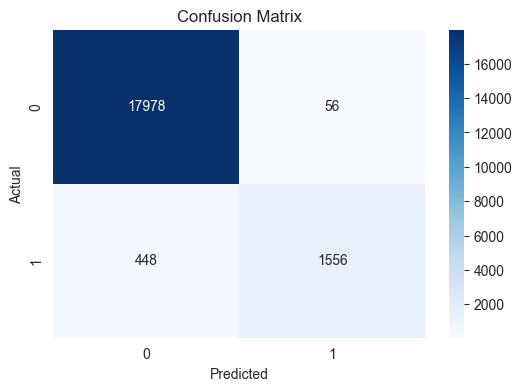

In [25]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

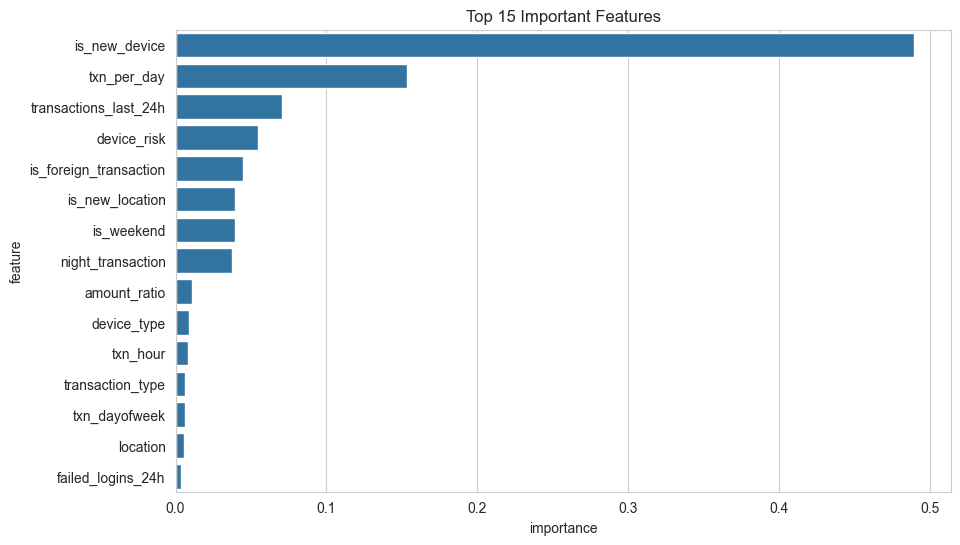

In [26]:
importance = best_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature':X_train_smote.columns,
    'importance':importance
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=feat_imp.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

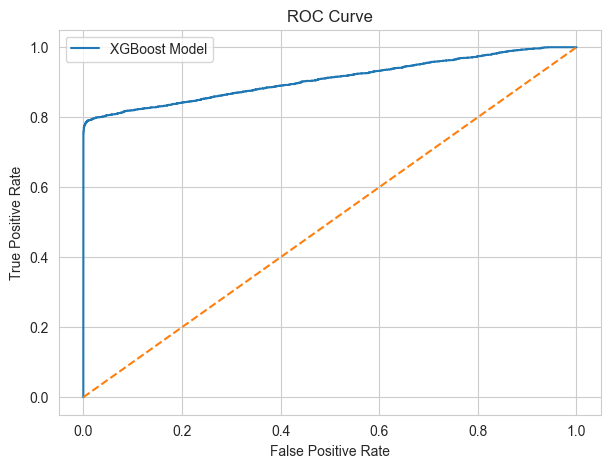

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="XGBoost Model")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [28]:
import joblib

joblib.dump(best_model, "fraud_detection_xgb_model.pkl")

print("Model saved successfully")

Model saved successfully


In [29]:
import json

features = list(X_train_smote.columns)

with open("model_features.json","w") as f:
    json.dump(features,f)